In [2]:
from qutip import *
import numpy as np
import matplotlib.pyplot as plt
import time
import scipy
import multiprocessing as mp
import multiprocessing
from scipy.sparse import csr_matrix
from scipy.integrate import solve_ivp
from scipy.optimize import curve_fit
import scipy.interpolate as interp 
import scipy.integrate as integrate
import cvxpy as cvx
import random
import itertools
from itertools import product## s1 for signal moment
from scipy.optimize import fsolve
from scipy.optimize import minimize


In [3]:
def spectrum_correlation_fft_not_real(tlist, y, inverse=False):
    """
    Calculate the power spectrum corresponding to a two-time correlation
    function using FFT.

    Parameters
    ----------
    tlist : array_like
        list/array of times :math:`t` which the correlation function is given.
    y : array_like
        list/array of correlations corresponding to time delays :math:`t`.
    inverse: bool, default: False
        boolean parameter for using a positive exponent in the Fourier
        Transform instead. Default is False.

    Returns
    -------
    w, S : tuple
        Returns an array of angular frequencies 'w' and the corresponding
        two-sided power spectrum 'S(w)'.

    """
    tlist = np.asarray(tlist)
    N = tlist.shape[0]
    dt = tlist[1] - tlist[0]
    if not np.allclose(np.diff(tlist), dt * np.ones(N - 1, dtype=float)):
        raise ValueError('tlist must be equally spaced for FFT.')
    F = (N * scipy.fftpack.ifft(y)) if inverse else scipy.fftpack.fft(y)
    # calculate the frequencies for the components in F
    f = scipy.fftpack.fftfreq(N, dt)
    # re-order frequencies from most negative to most positive (centre on 0)
    idx = np.array([], dtype='int')
    idx = np.append(idx, np.where(f < 0.0))
    idx = np.append(idx, np.where(f >= 0.0))
    return 2 * np.pi * f[idx], dt *F[idx]


In [2]:
## Try 1000 ns pulse length
## Try f0g1 simulation
Nqu=6;
Nres=3;
Nfilter=3;

## define qubit 
omegaq=2*np.pi*8027.77+2*np.pi*7;

aharmon=-2*np.pi*305.727-2*np.pi*18;

## Qubit have an intrisc infinite lifetime
qubitobj=basis(Nqu,2);
bqub=destroy(Nqu);
bqubd=create(Nqu);

## define resonator
omegares=2*np.pi*10266.36-2*np.pi*22 # data from Miyamura fitting
cfcoupling=2*np.pi*81.82;# data from Miyamura fitting

cavobj=basis(Nres);
acav=destroy(Nres);
acavd=create(Nres);

## define filter
omegafilter=2*np.pi*10173.87-2*np.pi*22; # data from Miyamura fitting
kappa=2*np.pi*180.35 # data from Miyamura fitting
filterobj=basis(Nfilter);
fcav=destroy(Nfilter);
fcavd=create(Nfilter);

##### 
c_ops=[];
c_ops.append(np.sqrt(kappa)*tensor(qeye(Nqu),qeye(Nres),fcav))
## qubit-resonator coupling strength
gqcav=2*np.pi*137.447*1.157*1.3;

## 2 chi=2.6MHz*2*pi from td-spectrum fitting
## operators for L operators

In [3]:
137.447*1.157*1.3

206.73403270000003

In [40]:
omega_rotate=2*np.pi*10000 # rotating, reduce the calculation burden?
H0=(omegaq-omega_rotate)*tensor(bqubd*bqub,qeye(Nres),qeye(Nfilter))+aharmon/2*tensor(bqubd*bqubd*bqub*bqub,qeye(Nres),qeye(Nfilter)) \
+(omegares-omega_rotate)*tensor(qeye(Nqu),acavd*acav,qeye(Nfilter))+gqcav*(tensor(bqub,acavd,qeye(Nfilter))+tensor(bqubd,acav,qeye(Nfilter)))\
+(omegafilter-omega_rotate)*tensor(qeye(Nqu),qeye(Nres),fcavd*fcav)+cfcoupling*(tensor(qeye(Nqu),acavd,fcav)+tensor(qeye(Nqu),acav,fcavd))

eigsystem=H0.eigenstates()

i0=tensor(basis(Nqu,4),cavobj,filterobj);
h0=tensor(basis(Nqu,3),cavobj,filterobj);
f0=tensor(basis(Nqu,2),cavobj,filterobj);
e0=tensor(basis(Nqu,1),cavobj,filterobj);
g0=tensor(basis(Nqu),cavobj,filterobj);

g1=tensor(basis(Nqu),basis(Nres,1),filterobj);
e1=tensor(basis(Nqu,1),basis(Nres,1),filterobj);

overlaplisti0=[fidelity(i0,eigsystem[1][cc]) for cc in range(len(eigsystem[0]))]
overlaplisth0=[fidelity(h0,eigsystem[1][cc]) for cc in range(len(eigsystem[0]))]
overlaplistf0=[fidelity(f0,eigsystem[1][cc]) for cc in range(len(eigsystem[0]))]
overlapliste0=[fidelity(e0,eigsystem[1][cc]) for cc in range(len(eigsystem[0]))]
overlaplistg0=[fidelity(g0,eigsystem[1][cc]) for cc in range(len(eigsystem[0]))]

overlaplistg1=[fidelity(g1,eigsystem[1][cc]) for cc in range(len(eigsystem[0]))]
overlapliste1=[fidelity(e1,eigsystem[1][cc]) for cc in range(len(eigsystem[0]))]

maxindexi0=overlaplisti0.index(max(overlaplisti0))
maxindexh0=overlaplisth0.index(max(overlaplisth0))
maxindexf0=overlaplistf0.index(max(overlaplistf0))
maxindexe0=overlapliste0.index(max(overlapliste0))
maxindexg0=overlaplistg0.index(max(overlaplistg0))

maxindexg11=overlaplistg1.index(max(overlaplistg1))
overlaplistg1.remove(max(overlaplistg1))
maxindexg12=overlaplistg1.index(max(overlaplistg1))

maxindexe11=overlapliste1.index(max(overlapliste1))
overlapliste1.remove(max(overlapliste1))
maxindexe12=overlapliste1.index(max(overlapliste1))

omegaf0g11=np.abs(eigsystem[0][maxindexf0]-eigsystem[0][maxindexg11])
omegah0e11=np.abs(eigsystem[0][maxindexh0]-eigsystem[0][maxindexe11])

omegaf0g12=np.abs(eigsystem[0][maxindexf0]-eigsystem[0][maxindexg12])
omegah0e12=np.abs(eigsystem[0][maxindexh0]-eigsystem[0][maxindexe12])

dressedf0=eigsystem[1][maxindexf0]
dressedg11=eigsystem[1][maxindexg11]
dressedg12=eigsystem[1][maxindexg12]

print("Energy of g0-e0="+str(eigsystem[0][maxindexe0]/2/np.pi))
print("Energy of e0-f0="+str(eigsystem[0][maxindexf0]/2/np.pi-eigsystem[0][maxindexe0]/2/np.pi))
print("Energy of f0-h0="+str(eigsystem[0][maxindexh0]/2/np.pi-eigsystem[0][maxindexf0]/2/np.pi))
print("Energy of h0-i0="+str(eigsystem[0][maxindexi0]/2/np.pi-eigsystem[0][maxindexh0]/2/np.pi))

print("Energy of g1-g0 mode 1="+str(eigsystem[0][maxindexg11]/2/np.pi))
print("Energy of g1-g0 mode 2="+str(eigsystem[0][maxindexg12]/2/np.pi))
print("Energy of e1-e0 mode 1="+str(eigsystem[0][maxindexe11]/2/np.pi-eigsystem[0][maxindexe0]/2/np.pi))
print("Energy of e1-e0 mode 2="+str(eigsystem[0][maxindexe12]/2/np.pi-eigsystem[0][maxindexe0]/2/np.pi))

Energy of g0-e0=-1984.4328327561589
Energy of e0-f0=-2303.3243605001744
Energy of f0-h0=-2623.8220399261218
Energy of h0-i0=-2945.292728355823
Energy of g1-g0 mode 1=306.47449899984883
Energy of g1-g0 mode 2=108.9583337563145
Energy of e1-e0 mode 1=302.87450553423264
Energy of e1-e0 mode 2=107.74498562836493


In [124]:
2303.3243605001744-1984.4328327561589

318.89152774401555

In [41]:
initialstatef0=eigsystem[1][maxindexf0]
initialstateh0=eigsystem[1][maxindexh0]
initialstatee0=eigsystem[1][maxindexe0]
initialstateg0=eigsystem[1][maxindexg0]

In [65]:
t=np.linspace(0,2,10001)
print("Max Freq = "+str(1.0/(t[1]-t[0])/2)+" MHz")

Max Freq = 2500.0 MHz


In [66]:
corr = correlation_2op_1t(H0, None, t, c_ops, tensor(qeye(Nqu),qeye(Nres),fcav), tensor(qeye(Nqu),qeye(Nres),fcav).dag())

In [67]:
wlist1, spec1 = spectrum_correlation_fft_not_real(t, corr)


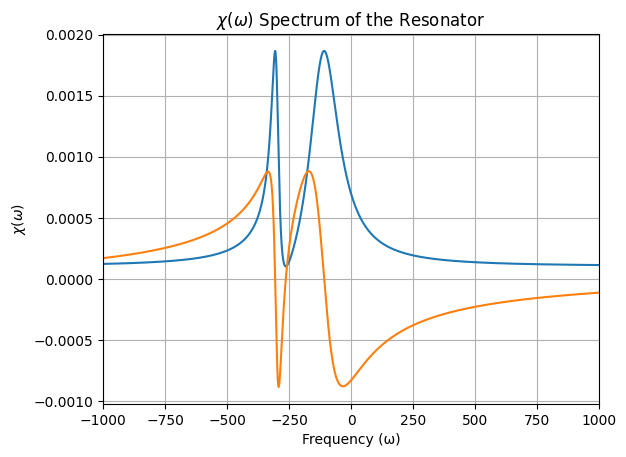

In [68]:
plt.plot(wlist1/2/np.pi,np.real(spec1))
plt.plot(wlist1/2/np.pi,np.imag(spec1))

plt.xlim([-11e3+omega_rotate/2/np.pi,-9e3+omega_rotate/2/np.pi])
plt.xlabel("Frequency (ω)")
plt.ylabel("$\chi(\omega)$")
plt.title("$\chi(\omega)$ Spectrum of the Resonator")
plt.grid()
plt.show()


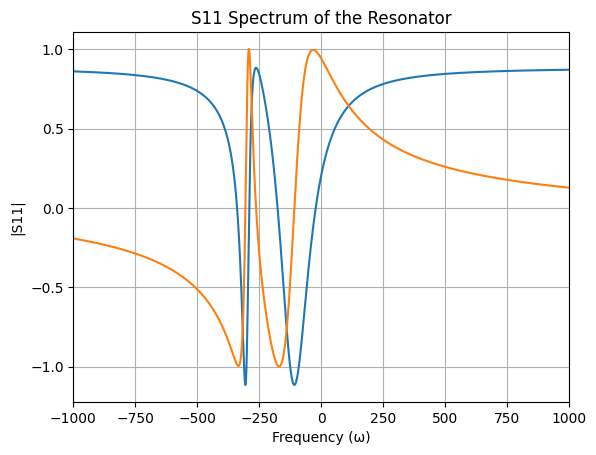

In [71]:
plt.plot(wlist1/2/np.pi,np.real(1-kappa*spec1))
plt.plot(wlist1/2/np.pi,np.imag(1-kappa*spec1))

plt.xlim([-11e3+omega_rotate/2/np.pi,-9e3+omega_rotate/2/np.pi])
plt.xlabel("Frequency (ω)")
plt.ylabel("|S11|")
plt.title("S11 Spectrum of the Resonator")
plt.grid()
plt.show()


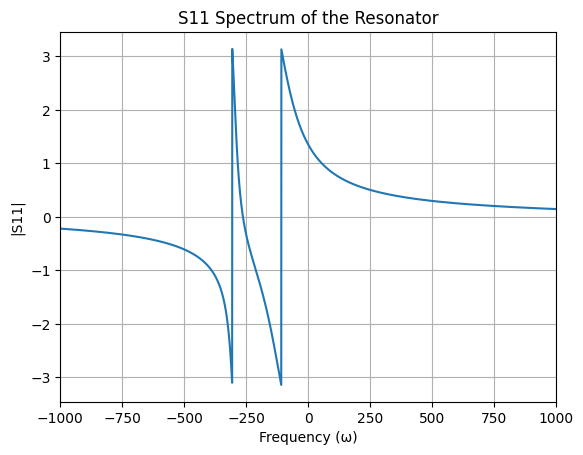

In [72]:
plt.plot(wlist1/2/np.pi,np.angle(1-kappa*spec1))
plt.xlim([-11e3+omega_rotate/2/np.pi,-9e3+omega_rotate/2/np.pi])
plt.xlabel("Frequency (ω)")
plt.ylabel("|S11|")
plt.title("S11 Spectrum of the Resonator")
plt.grid()
plt.show()


In [73]:
## calculate the ground cavity and excited cavity correlation function <a*a^+>
intial_oper_state_for_ground=tensor(qeye(Nqu),qeye(Nres),fcav).dag()*initialstateg0*initialstateg0.dag()
intial_oper_state_for_excited=tensor(qeye(Nqu),qeye(Nres),fcav).dag()*initialstatee0*initialstatee0.dag()

In [74]:
output_tmp_ground = mesolve(H0, intial_oper_state_for_ground, t, c_ops,progress_bar=True)
output_tmp_excited = mesolve(H0, intial_oper_state_for_excited, t, c_ops,progress_bar=True)

10.0%. Run time:   1.55s. Est. time left: 00:00:00:13
20.0%. Run time:   3.11s. Est. time left: 00:00:00:12
30.0%. Run time:   4.68s. Est. time left: 00:00:00:10
40.0%. Run time:   6.24s. Est. time left: 00:00:00:09
50.0%. Run time:   7.79s. Est. time left: 00:00:00:07
60.0%. Run time:   9.36s. Est. time left: 00:00:00:06
70.0%. Run time:  10.91s. Est. time left: 00:00:00:04
80.0%. Run time:  12.47s. Est. time left: 00:00:00:03
90.0%. Run time:  14.03s. Est. time left: 00:00:00:01
Total run time:  15.60s
10.0%. Run time:   1.77s. Est. time left: 00:00:00:15
20.0%. Run time:   3.74s. Est. time left: 00:00:00:14
30.0%. Run time:   5.72s. Est. time left: 00:00:00:13
40.0%. Run time:   7.69s. Est. time left: 00:00:00:11
50.0%. Run time:   9.66s. Est. time left: 00:00:00:09
60.0%. Run time:  11.64s. Est. time left: 00:00:00:07
70.0%. Run time:  13.61s. Est. time left: 00:00:00:05
80.0%. Run time:  15.58s. Est. time left: 00:00:00:03
90.0%. Run time:  17.56s. Est. time left: 00:00:00:01
Tota

In [75]:
corr_ground=[np.trace(tensor(qeye(Nqu),qeye(Nres),fcav)*output_tmp_ground.states[cc]) for cc in range(len(t))]
corr_excited=[np.trace(tensor(qeye(Nqu),qeye(Nres),fcav)*output_tmp_excited.states[cc]) for cc in range(len(t))]

In [76]:
[wlist1[0]/2/np.pi,wlist1[-1]/2/np.pi]

[-2499.7500249975, 2499.7500249975]

In [77]:
wlist1, spec_ground = spectrum_correlation_fft_not_real(t, corr_ground)
wlist1, spec_excited = spectrum_correlation_fft_not_real(t, corr_excited)

In [158]:
wlist1[list(np.real(spec_ground)).index(max(np.real(spec_ground)))]/2/np.pi

-306.4693530646935

In [159]:
wlist1[list(np.real(spec_excited)).index(max(np.real(spec_excited)))]/2/np.pi

-107.98920107989201

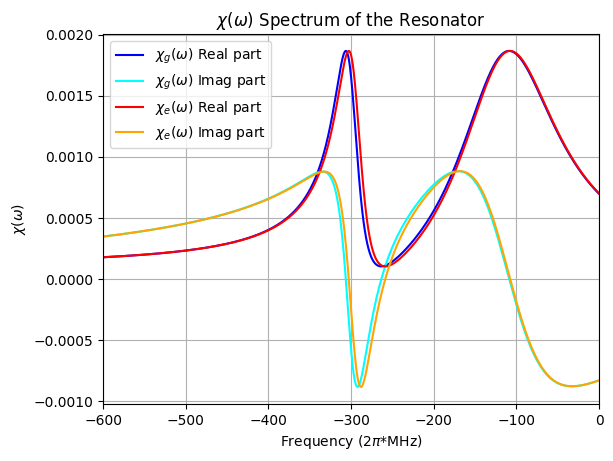

In [78]:
plt.plot(wlist1/2/np.pi,np.real(spec_ground),label="$\chi_g(\omega)$ Real part",color="blue")
plt.plot(wlist1/2/np.pi,np.imag(spec_ground),label="$\chi_g(\omega)$ Imag part",color="cyan")
# plt.plot(wlist1/2/np.pi,np.real(spec1))
# plt.plot(wlist1/2/np.pi,np.imag(spec1))

plt.plot(wlist1/2/np.pi,np.real(spec_excited),label="$\chi_e(\omega)$ Real part",color="red")
plt.plot(wlist1/2/np.pi,np.imag(spec_excited),label="$\chi_e(\omega)$ Imag part",color="orange")
plt.legend()
plt.xlim([-10.6e3+omega_rotate/2/np.pi,-10.0e3+omega_rotate/2/np.pi])
plt.xlabel("Frequency (2$\pi$*MHz)")
plt.ylabel("$\chi(\omega)$")
plt.title("$\chi(\omega)$ Spectrum of the Resonator")
plt.grid()
plt.show()

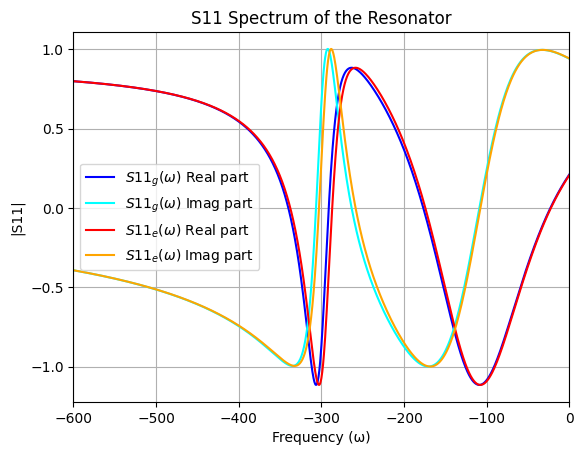

In [79]:
plt.plot(wlist1/2/np.pi,np.real(1-kappa*spec_ground),label="$S11_g(\omega)$ Real part",color="blue")
plt.plot(wlist1/2/np.pi,np.imag(1-kappa*spec_ground),label="$S11_g(\omega)$ Imag part",color="cyan")

plt.plot(wlist1/2/np.pi,np.real(1-kappa*spec_excited),label="$S11_e(\omega)$ Real part",color="red")
plt.plot(wlist1/2/np.pi,np.imag(1-kappa*spec_excited),label="$S11_e(\omega)$ Imag part",color="orange")
plt.legend()
plt.xlim([-10.6e3+omega_rotate/2/np.pi,-10.0e3+omega_rotate/2/np.pi])
plt.xlabel("Frequency (ω)")
plt.ylabel("|S11|")
plt.title("S11 Spectrum of the Resonator")
plt.grid()
plt.show()

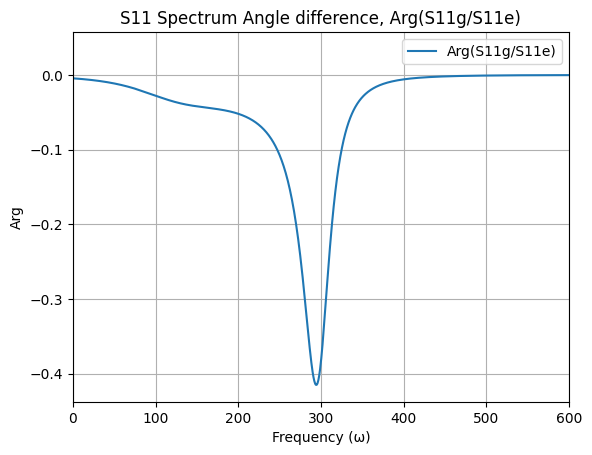

In [85]:
plt.plot(-wlist1/2/np.pi,np.angle((1-kappa*spec_ground)/(1-kappa*spec_excited)),label='Arg(S11g/S11e)')
plt.legend()
plt.xlim([10.0e3-omega_rotate/2/np.pi,10.6e3-omega_rotate/2/np.pi])
plt.xlabel("Frequency (ω)")
plt.ylabel("Arg")
plt.title("S11 Spectrum Angle difference, Arg(S11g/S11e)")
plt.grid()
plt.show()

In [87]:
wlist1/2/np.pi

array([-2499.750025  , -2499.25007499, -2498.75012499, ...,
        2498.75012499,  2499.25007499,  2499.750025  ])

In [98]:
w_exp = wlist1/2/np.pi  # Experimental frequency points notice for the spectrum calculation, it would be negative
angle_exp =np.angle((1-kappa*spec_ground)/(1-kappa*spec_excited)) ## the angle spectrum of the system

w_pick_up_range_lb=-600*2*np.pi
w_pick_up_range_ub=0*2*np.pi
mask = (w_exp >= w_pick_up_range_lb/2/np.pi) & (w_exp <= w_pick_up_range_ub/2/np.pi)
w_exp_picked=w_exp[mask] # without 2pi on frequency
angle_exp_picked=angle_exp[mask]


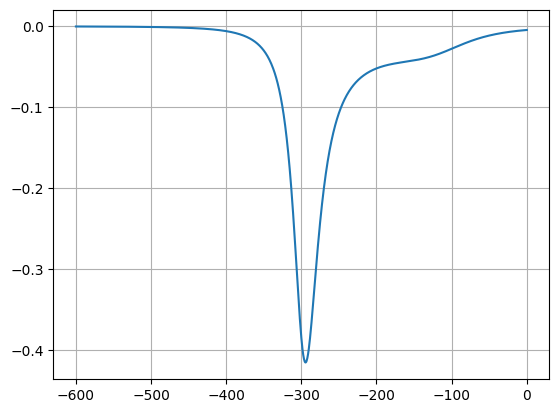

In [97]:
plt.plot(w_exp_picked,angle_exp_picked)
plt.grid()
plt.show()

In [5]:
## fitting the Hamiltonian parameters from the specturm
## Might take huge time
# Define the Hamiltonian model
def theoretical_spectrum_with_freq_range(params, t, w_pick_up_range_lb,w_pick_up_range_ub):
    wc, wq, wf, ahar, g, J, kappa = params  
    # Parameters: cavity freq, qubit freq, filter freq, anharmonicity, qubit-res coupling strength, res-filter coupleing strength, decay rate, 
    levelsq=6 # Hilbert space size of qubit, Not regarded as a fit parameter here, but can be
    levels=3  # Hilbert space size of resonator, Not regarded as a fit parameter here, but can be    
    levelsf=3 # Hilbert space size of filter, Not regarded as a fit parameter here, but can be
   
    a = destroy(int(levels))    # Cavity annihilation operator
    cavobj_tmp=basis(levels)    # Cavity zero state
    
    b = destroy(int(levelsq))    # Qubit annihilation operator
    
    f = destroy(int(levelsf))    # Filter annihilation operator
    filterobj_tmp=basis(levelsf)    # filter zero state

    H=(wq-omega_rotate)*tensor(b.dag()*b,qeye(levels),qeye(levelsf))+ahar/2*tensor(b.dag()*b.dag()*b*b,qeye(levels),qeye(levelsf)) \
    +(wc-omega_rotate)*tensor(qeye(levelsq),a.dag()*a,qeye(levelsf))+g*(tensor(b,a.dag(),qeye(levelsf))+tensor(b.dag(),a,qeye(levelsf)))\
    +(wf-omega_rotate)*tensor(qeye(levelsq),qeye(levels),f.dag()*f)+J*(tensor(qeye(levelsq),a.dag(),f)+tensor(qeye(levelsq),a,f.dag()))

    ## system Hamiltonian
    
    ## get the initial state of the dressed system
    eigsystem_tmp=H.eigenstates()
    e0=tensor(basis(levelsq,1),cavobj_tmp,filterobj_tmp);
    g0=tensor(basis(levelsq),cavobj_tmp,filterobj_tmp);
    overlapliste0=[fidelity(e0,eigsystem[1][cc]) for cc in range(len(eigsystem[0]))]
    overlaplistg0=[fidelity(g0,eigsystem[1][cc]) for cc in range(len(eigsystem[0]))]

    initialstatee0=eigsystem_tmp[1][maxindexe0]
    initialstateg0=eigsystem_tmp[1][maxindexg0]

    c_ops = [np.sqrt(kappa) * tensor(qeye(levelsq),qeye(levels),f)]  # Collapse operator for decay
    
    ## calculate the ground cavity
    intial_oper_state_for_ground=tensor(qeye(levelsq),qeye(levels),f).dag()*initialstateg0*initialstateg0.dag()
    intial_oper_state_for_excited=tensor(qeye(levelsq),qeye(levels),f).dag()*initialstatee0*initialstatee0.dag()

    output_tmp_ground_tmp = mesolve(H, intial_oper_state_for_ground, t, c_ops)
    output_tmp_excited_tmp = mesolve(H, intial_oper_state_for_excited, t, c_ops)

    corr_ground_tmp=[np.trace(tensor(qeye(Nqu),qeye(levels),f)*output_tmp_ground_tmp.states[cc]) for cc in range(len(t))]
    corr_excited_tmp=[np.trace(tensor(qeye(Nqu),qeye(levels),f)*output_tmp_excited_tmp.states[cc]) for cc in range(len(t))]

    wlist1, spec_ground_tmp = spectrum_correlation_fft_not_real(t, corr_ground_tmp)
    wlist1, spec_excited_tmp = spectrum_correlation_fft_not_real(t, corr_excited_tmp)
    ## return the angle spectrum of the system, if want to fit with other parameters than fit with other parameters
    angle_theory =np.angle((1-kappa*spec_ground_tmp)/(1-kappa*spec_excited_tmp)) 

    # Apply logical indexing
    mask = (wlist1 >= w_pick_up_range_lb) & (wlist1 <= w_pick_up_range_ub)
    selected_angle_theory = angle_theory[mask]
    selected_wlist1 = wlist1[mask]
    return selected_wlist1, selected_angle_theory

In [138]:
## fitting the Hamiltonian parameters from the specturm
## Might take huge time

# Define the cost function for fitting
def cost_function_with_bound(params):
    wlist1_cal, angle_theory = theoretical_spectrum_with_freq_range(params, t, w_pick_up_range_lb, w_pick_up_range_ub)  # Simulated spectrum
    return np.sum((angle_theory - angle_exp_picked)**2)  # Sum of squared differences
# Callback function to track progress
params_history = []
objective_history = []

def callback(params):
    params_history.append(params)
    obj_value = cost_function_with_bound(params)
    objective_history.append(obj_value)
    print(f"Iteration: {len(objective_history)}, Params: {params}, Obj Value: {obj_value}")

# Initial guess for parameters
params_initial = [2*np.pi*10250, 2*np.pi*8015,2*np.pi*10200, -2*np.pi*320,2*np.pi*170,2*np.pi*100,2*np.pi*175] # [wc, wq, ahar, g, kappa, levels]
# Initial guess for parameters, use very close to real parameters
# params_initial = [2*np.pi*10244, 2*np.pi*8034, 2*np.pi*10152, -2*np.pi*323, 2*np.pi*207,2*np.pi*80,2*np.pi*180]  # [wc, wq, ahar, g, kappa, levels]

# Perform the optimization
result = minimize(cost_function_with_bound, params_initial, bounds=[(2*np.pi*9000,2*np.pi*9700), (2*np.pi*8000,2*np.pi*8100),(2*np.pi*10000,2*np.pi*10300),\
                                                                    (-2*np.pi*330,-2*np.pi*300),(2*np.pi*150,2*np.pi*250),(2*np.pi*50,2*np.pi*150),(2*np.pi*50,2*np.pi*200)], callback=callback)
# wc, wq, wf, ahar, g, J, kappa
# Extract the best-fit parameters
wc_fit, wq_fit, wf_fit, ahar_fit, g_fit, J_fit, kappa_fit  = result.x
print(f"Fitted parameters (in unit of 2pi* MHz): wc = {wc_fit/2/np.pi}, wq = {wq_fit/2/np.pi}, wf = {wf_fit/2/np.pi}\
anharmonicity = {ahar_fit/2/np.pi}, Qubit-res coupling g= {g_fit/2/np.pi}, Res-filter coupling J= {J_fit/2/np.pi}, kappa = {kappa_fit/2/np.pi}")


Iteration: 1, Params: [64402.64000451 50359.73044076 64088.48556128 -2010.6212532
  1068.14816523   628.2981632   1099.56323235], Obj Value: 5.106914510346465
Iteration: 2, Params: [64354.16226401 50362.91085745 64083.69360719 -2012.8917538
  1103.79772161   518.46131789  1093.15074944], Obj Value: 2.6109719204551998
Iteration: 3, Params: [64352.46852429 50367.23806539 64071.95544989 -2018.01712236
  1136.4710038    465.03779785  1086.44891761], Obj Value: 1.9297199200246813
Iteration: 4, Params: [64402.34229016 50370.91843537 64045.82934507 -2030.52421013
  1209.53297413   398.78961251  1073.81372641], Obj Value: 0.7387235111858447
Iteration: 5, Params: [64436.36538156 50373.58651803 64034.06902515 -2036.41725058
  1241.52281867   386.98143504  1069.18861387], Obj Value: 0.19729319548896374
Iteration: 6, Params: [64443.33204379 50373.53579233 64036.38880783 -2036.65200805
  1237.06447929   410.07203624  1071.70356786], Obj Value: 0.09341839092477872
Iteration: 7, Params: [64441.782380

In [139]:
[omegares/2/np.pi,omegaq/2/np.pi,omegafilter/2/np.pi,aharmon/2/np.pi,gqcav/2/np.pi,cfcoupling/2/np.pi,kappa/2/np.pi]

[10244.36,
 8034.770000000001,
 10151.87,
 -323.727,
 206.73403270000003,
 81.82,
 180.35]

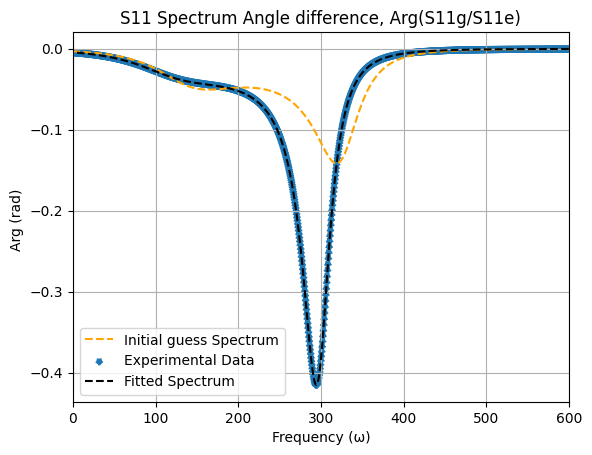

In [140]:
params_initial = [2*np.pi*10250, 2*np.pi*8015,2*np.pi*10200, -2*np.pi*320,2*np.pi*170,2*np.pi*100,2*np.pi*175]
w_tmp, S_fit_initial = theoretical_spectrum_with_freq_range(params_initial, t, w_pick_up_range_lb,w_pick_up_range_ub)
w_tmp, S_fit = theoretical_spectrum_with_freq_range(result.x, t, w_pick_up_range_lb,w_pick_up_range_ub)
plt.figure()
plt.plot(-w_tmp/2/np.pi, S_fit_initial, label="Initial guess Spectrum", linestyle="dashed",color="orange")

plt.scatter(-w_tmp/2/np.pi, angle_exp_picked, label="Experimental Data", linestyle="dotted",s=20)
plt.plot(-w_tmp/2/np.pi, S_fit, label="Fitted Spectrum", linestyle="dashed",color="black")

plt.xlim([-w_pick_up_range_ub/2/np.pi,-w_pick_up_range_lb/2/np.pi])
plt.xlabel("Frequency (ω)")
plt.ylabel("Arg (rad) ")
plt.legend()
plt.title("S11 Spectrum Angle difference, Arg(S11g/S11e)")
plt.grid()
plt.show()


In [249]:
result.x/2/np.pi  # Parameters: cavity freq, qubit freq, filter freq, anharmonicity, qubit-res coupling strength, res-filter coupleing strength, decay rate, 
# params_initial = [2*np.pi*10244, 2*np.pi*8034, 2*np.pi*10152, -2*np.pi*323, 2*np.pi*207,2*np.pi*80,2*np.pi*180]  # [wc, wq, ahar, g, kappa, levels]


array([10243.76545153,  8008.8639999 , 10152.29080293,  -318.93148187,
         210.4351602 ,    81.78125235,   179.35980558])

In [134]:
# w_tmp, S_fit = theoretical_spectrum_with_freq_range(result.x, t, w_pick_up_range_lb,w_pick_up_range_ub)
# params_initial = [2*np.pi*10270, 2*np.pi*8015,2*np.pi*10200, -2*np.pi*320,2*np.pi*170,2*np.pi*100,2*np.pi*175]   # Parameters: cavity freq, qubit freq, filter freq, anharmonicity, qubit-res coupling strength, res-filter coupleing strength, decay rate, 
params_initial = [2*np.pi*10244, 2*np.pi*8034, 2*np.pi*10152, -2*np.pi*323, 2*np.pi*207,2*np.pi*80,2*np.pi*180]   # Parameters: cavity freq, qubit freq, filter freq, anharmonicity, qubit-res coupling strength, res-filter coupleing strength, decay rate, 
w_tmp, S_fit_initial = theoretical_spectrum_with_freq_range(params_initial, t, w_pick_up_range_lb,w_pick_up_range_ub)

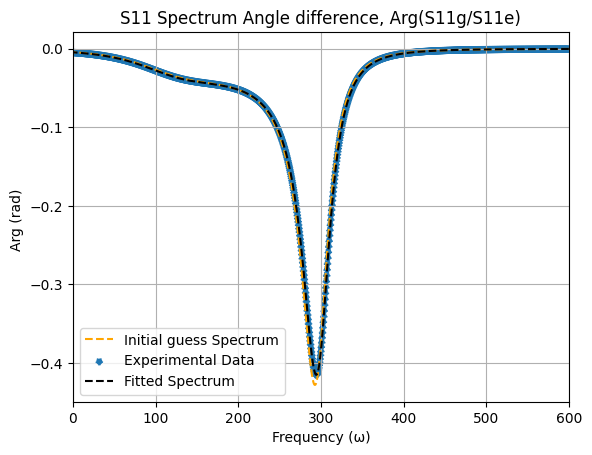

In [135]:
plt.figure()
plt.plot(-w_tmp/2/np.pi, S_fit_initial, label="Initial guess Spectrum", linestyle="dashed",color="orange")

plt.scatter(-w_tmp/2/np.pi, angle_exp_picked, label="Experimental Data", linestyle="dotted",s=20)
plt.plot(-w_tmp/2/np.pi, S_fit, label="Fitted Spectrum", linestyle="dashed",color="black")

plt.xlim([-w_pick_up_range_ub/2/np.pi,-w_pick_up_range_lb/2/np.pi])
plt.xlabel("Frequency (ω)")
plt.ylabel("Arg (rad) ")
plt.legend()
plt.title("S11 Spectrum Angle difference, Arg(S11g/S11e)")
plt.grid()
plt.show()


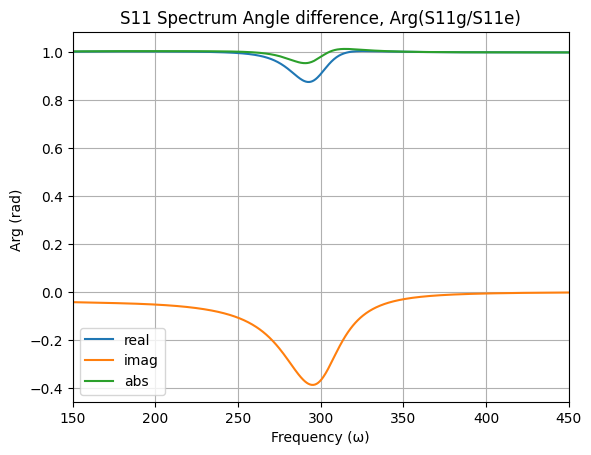

In [206]:
## get an initial guess from the measured spectrum from Arg(S11_g/S11_e)!
w_exp = wlist1/2/np.pi  # Experimental frequency points notice for the spectrum calculation, it would be negative
data_exp =(1-kappa*spec_ground)/(1-kappa*spec_excited) ## the angle spectrum of the system

# w_pick_up_range_lb=-600*2*np.pi
# w_pick_up_range_ub=0*2*np.pi

w_pick_up_range_lb=-450*2*np.pi
w_pick_up_range_ub=-150*2*np.pi
mask = (w_exp >= w_pick_up_range_lb/2/np.pi) & (w_exp <= w_pick_up_range_ub/2/np.pi)
w_exp_picked=w_exp[mask] # without 2pi on frequency
data_exp_picked=data_exp[mask]


plt.plot(-w_exp_picked,np.real(data_exp_picked),label="real")
plt.plot(-w_exp_picked,np.imag(data_exp_picked),label="imag")
plt.plot(-w_exp_picked,np.abs(data_exp_picked),label="abs")
plt.xlim([-w_pick_up_range_ub/2/np.pi,-w_pick_up_range_lb/2/np.pi])
plt.xlabel("Frequency (ω)")
plt.ylabel("Arg (rad) ")
plt.legend()
plt.title("S11 Spectrum Angle difference, Arg(S11g/S11e)")
plt.grid()
plt.show()


In [207]:
initial_guess

[10306, 10304, 50]

[[Model]]
    Model(single_resonator_ratio_func)
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 737
    # data points      = 1200
    # variables        = 4
    chi-square         = 0.34379905
    reduced chi-square = 2.8746e-04
    Akaike info crit   = -9781.32974
    Bayesian info crit = -9760.96943
    R-squared          = (208851668339380.47+49711470862541.37j)
[[Variables]]
    omega_res_ground:   10293.9705 +/- 0.15699613 (0.00%) (init = 10306)
    omega_res_excited:  10289.5068 +/- 0.15700488 (0.00%) (init = 10304)
    kappa:              43.8161228 +/- 0.44316113 (1.01%) (init = 50)
    kappa_int:          3.6508e-07 +/- 2.99978168 (821667913.47%) (init = 1)
[[Correlations]] (unreported correlations are < 0.100)
    C(omega_res_ground, omega_res_excited) = +0.9795
2$\chi$ (2pi*MHz)= -4.463668548889473


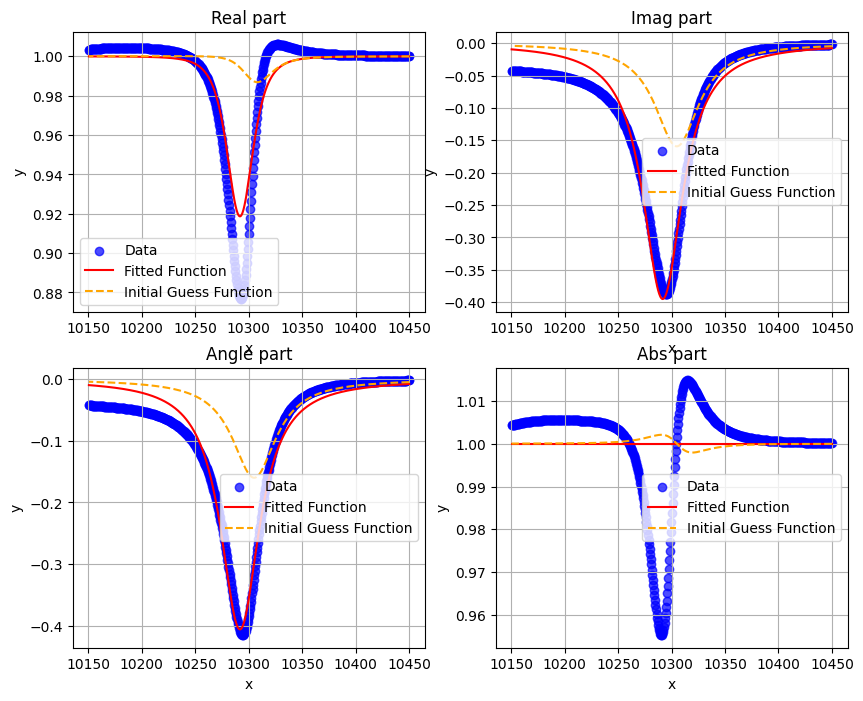

In [208]:
import lmfit as lmf

## Single resonator model
def single_resonator_ratio_func(omega,omega_res_ground,omega_res_excited, kappa, kappa_int):
    # omega_res_ground,omega_res_excited, kappa= params
    s11_g=1-kappa/(kappa/2+kappa_int/2+1j*(omega_res_ground-omega))
    s11_e=1-kappa/(kappa/2+kappa_int/2+1j*(omega_res_excited-omega))
    return s11_g/s11_e

# Generate synthetic data for demonstration
x_data = -w_exp_picked+omega_rotate/2/np.pi  # Independent variable
y_data = data_exp_picked  # Add noise

def guess_params_dp(data,x):
    par_ini = {"omega_res_ground":10306, "omega_res_excited":10304, "kappa":50, "kappa_int":1}
    par_max = {"omega_res_ground":10400, "omega_res_excited":10400, "kappa":100, "kappa_int":10}
    par_min = {"omega_res_ground":10000, "omega_res_excited":10000, "kappa":10, "kappa_int":0}
    par_vary = {"omega_res_ground":1, "omega_res_excited":1, "kappa":1, "kappa_int":1}
    return par_ini,par_max,par_min,par_vary
    
def probe_resonator_fit_single(data, x):
    model = lmf.Model(single_resonator_ratio_func, nan_policy='omit')
    params = model.make_params()
    par_ini,par_max,par_min,par_vary=guess_params_dp(data,x)
    for name in params:
        params[name].set(
            value=par_ini[name],  # 初期値
            min=par_min[name],  # 下限値
            max=par_max[name],  # 上限値
            vary=par_vary[name] # パラメータを動かすかどうか
        )
    result=model.fit(data, omega=x, params=params, method='leastsq')
    return result

fit_single_res=probe_resonator_fit_single(y_data,x_data)

print(fit_single_res.fit_report())
print("2$\chi$ (2pi*MHz)=",-fit_single_res.params["omega_res_ground"].value+fit_single_res.params["omega_res_excited"].value)
# Plot the results
plt.figure(figsize=(10, 8))
plt.subplot(221)
plt.scatter(x_data, np.real(y_data), label="Data", color="blue", alpha=0.7)
plt.plot(x_data, np.real(fit_single_res.best_fit), label="Fitted Function", color="red")
plt.plot(x_data, np.real(fit_single_res.init_fit), label="Initial Guess Function", color="orange",linestyle="dashed")

plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.title("Real part")
plt.grid()

plt.subplot(222)
plt.scatter(x_data, np.imag(y_data), label="Data", color="blue", alpha=0.7)
plt.plot(x_data, np.imag(fit_single_res.best_fit), label="Fitted Function", color="red")
plt.plot(x_data, np.imag(fit_single_res.init_fit), label="Initial Guess Function", color="orange",linestyle="dashed")

plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.title("Imag part")
plt.grid()

plt.subplot(223)
plt.scatter(x_data, np.angle(y_data), label="Data", color="blue", alpha=0.7)
plt.plot(x_data, np.angle(fit_single_res.best_fit), label="Fitted Function", color="red")
plt.plot(x_data, np.angle(fit_single_res.init_fit), label="Initial Guess Function", color="orange",linestyle="dashed")

plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.title("Angle part")
plt.grid()

plt.subplot(224)
plt.scatter(x_data, np.abs(y_data), label="Data", color="blue", alpha=0.7)
plt.plot(x_data, np.abs(fit_single_res.best_fit), label="Fitted Function", color="red")
plt.plot(x_data, np.abs(fit_single_res.init_fit), label="Initial Guess Function", color="orange",linestyle="dashed")

plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.title("Abs part")
plt.grid()

In [4]:
## Resonator-filter model
def s11_ge_dp(f, f_r_g, f_r_e, f_f, k_ex, k_in, g, gamma, phi):
    k_tot = k_ex + k_in
    s11_g = np.cos(phi) + np.exp(1j*phi) * k_ex * (1j*(f-f_r_g) - gamma/2)/((1j*(f-f_f)-k_tot/2) * (1j*(f-f_r_g)-gamma/2) + g**2)
    s11_e = np.cos(phi) + np.exp(1j*phi) * k_ex * (1j*(f-f_r_e) - gamma/2)/((1j*(f-f_f)-k_tot/2) * (1j*(f-f_r_e)-gamma/2) + g**2)
    return (s11_g/s11_e)
def guess_params_dp(data,x):
    par_ini = {"f_r_g":9377,"f_r_e":9371, "f_f":9395, "k_ex":95, "k_in":2, "g":167, "gamma":0, "phi":0,}
    # par_ini = {"f_r_g":10300,"f_r_e":10288, "f_f":10280, "k_ex":100, "k_in":2, "g":80, "gamma":0, "phi":0,}
    par_max = {"f_r_g":9700,"f_r_e":9700, "f_f":9700, "k_ex":800, "k_in":10, "g":300, "gamma":.3, "phi":2 * np.pi,}
    par_min = {"f_r_g":9000, "f_r_e":9000,"f_f":9000, "k_ex":0, "k_in":0, "g":0, "gamma":0, "phi":-2*np.pi,}
    par_vary = {"f_r_g":1, "f_r_e":1,"f_f":True, "k_ex":1, "k_in":1, "chi":True, "g":1, "gamma":0, "phi":1}
    return par_ini,par_max,par_min,par_vary
def probe_resonator_fit_double(data, x):
    import lmfit as lmf
    model = lmf.Model(s11_ge_dp, nan_policy='omit')
    params = model.make_params()
    par_ini,par_max,par_min,par_vary=guess_params_dp(data,x)
    for name in params:
        params[name].set(
            value=par_ini[name],  # 初期値
            min=par_min[name],  # 下限値
            max=par_max[name],  # 上限値
            vary=par_vary[name] # パラメータを動かすかどうか
        )
    result=model.fit(data, f=x, params=params, method='leastsq')
    return result

[[Model]]
    Model(s11_ge_dp)
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 16000
    # data points      = 1200
    # variables        = 7
    chi-square         = 0.07696012
    reduced chi-square = 6.4510e-05
    Akaike info crit   = -11571.4537
    Bayesian info crit = -11535.8231
    R-squared          = (-35382242277541.87+38714203562759.22j)
##  Warning: uncertainties could not be estimated:
[[Variables]]
    f_r_g:  10274.4305 (init = 10300)
    f_r_e:  10270.0483 (init = 10288)
    f_f:    10191.3437 (init = 10280)
    k_ex:   203.287989 (init = 180)
    k_in:   7.1701e-05 (init = 2)
    g:      64.1122267 (init = 80)
    gamma:  0 (fixed)
    phi:   -0.04696052 (init = 0)
2$\chi$ (2pi*MHz)= -4.382195079639132


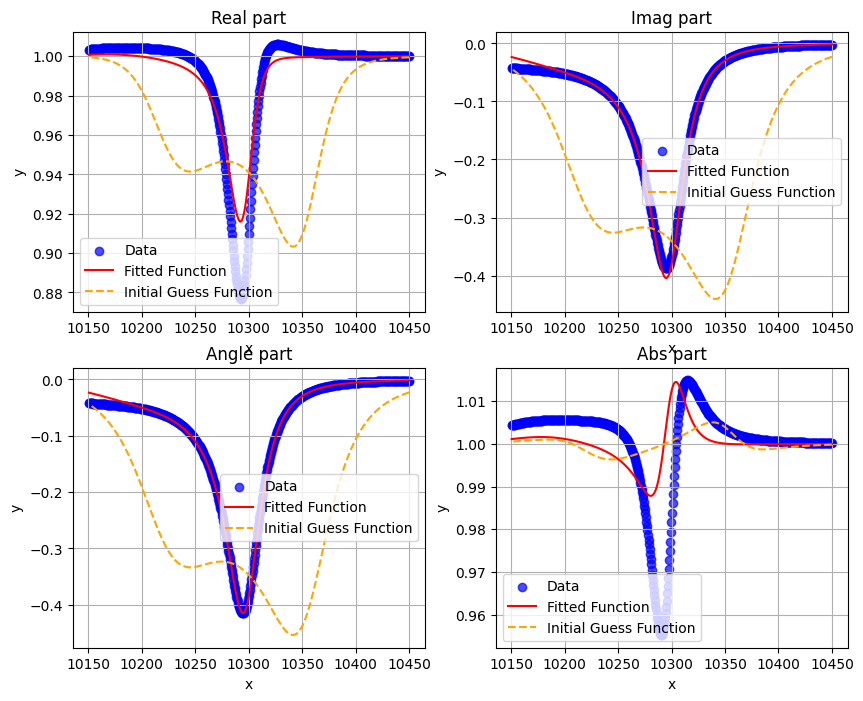

In [255]:

fit_double_res=probe_resonator_fit_double(y_data,x_data)

print(fit_double_res.fit_report())
print("2$\chi$ (2pi*MHz)=",-fit_double_res.params["f_r_g"].value+fit_double_res.params["f_r_e"].value)
# Plot the results
plt.figure(figsize=(10, 8))
plt.subplot(221)
plt.scatter(x_data, np.real(y_data), label="Data", color="blue", alpha=0.7)
plt.plot(x_data, np.real(fit_double_res.best_fit), label="Fitted Function", color="red")
plt.plot(x_data, np.real(fit_double_res.init_fit), label="Initial Guess Function", color="orange",linestyle="dashed")

plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.title("Real part")
plt.grid()

plt.subplot(222)
plt.scatter(x_data, np.imag(y_data), label="Data", color="blue", alpha=0.7)
plt.plot(x_data, np.imag(fit_double_res.best_fit), label="Fitted Function", color="red")
plt.plot(x_data, np.imag(fit_double_res.init_fit), label="Initial Guess Function", color="orange",linestyle="dashed")

plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.title("Imag part")
plt.grid()

plt.subplot(223)
plt.scatter(x_data, np.angle(y_data), label="Data", color="blue", alpha=0.7)
plt.plot(x_data, np.angle(fit_double_res.best_fit), label="Fitted Function", color="red")
plt.plot(x_data, np.angle(fit_double_res.init_fit), label="Initial Guess Function", color="orange",linestyle="dashed")

plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.title("Angle part")
plt.grid()

plt.subplot(224)
plt.scatter(x_data, np.abs(y_data), label="Data", color="blue", alpha=0.7)
plt.plot(x_data, np.abs(fit_double_res.best_fit), label="Fitted Function", color="red")
plt.plot(x_data, np.abs(fit_double_res.init_fit), label="Initial Guess Function", color="orange",linestyle="dashed")

plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.title("Abs part")
plt.grid()

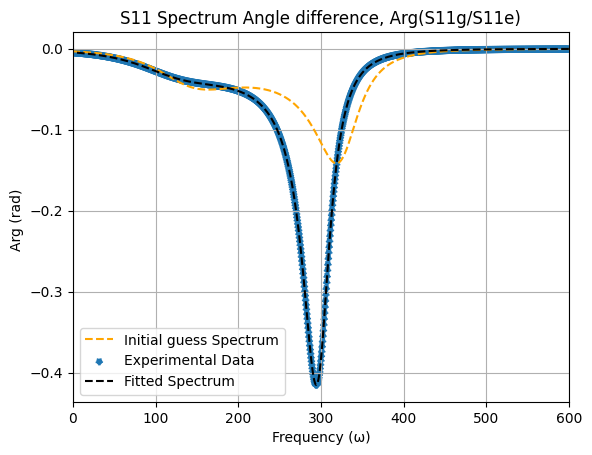

In [137]:
params_initial = [2*np.pi*10250, 2*np.pi*8015,2*np.pi*10200, -2*np.pi*320,2*np.pi*170,2*np.pi*100,2*np.pi*175]
w_tmp, S_fit_initial = theoretical_spectrum_with_freq_range(params_initial, t, w_pick_up_range_lb,w_pick_up_range_ub)
w_tmp, S_fit = theoretical_spectrum_with_freq_range(result.x, t, w_pick_up_range_lb,w_pick_up_range_ub)
plt.figure()
plt.plot(-w_tmp/2/np.pi, S_fit_initial, label="Initial guess Spectrum", linestyle="dashed",color="orange")

plt.scatter(-w_tmp/2/np.pi, angle_exp_picked, label="Experimental Data", linestyle="dotted",s=20)
plt.plot(-w_tmp/2/np.pi, S_fit, label="Fitted Spectrum", linestyle="dashed",color="black")

plt.xlim([-w_pick_up_range_ub/2/np.pi,-w_pick_up_range_lb/2/np.pi])
plt.xlabel("Frequency (ω)")
plt.ylabel("Arg (rad) ")
plt.legend()
plt.title("S11 Spectrum Angle difference, Arg(S11g/S11e)")
plt.grid()
plt.show()
